In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("Customer Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Replacing blanks with 0 as tenure is 0 and no total charges is recorded

In [9]:
df["TotalCharges"] = df["TotalCharges"].replace(" ",0)
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [11]:
print(df.isnull().sum().sum())

0


In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [13]:
print(df["customerID"].duplicated().sum())

0


In [14]:
def conv(value):
    if value == 1:
        return "Yes"
    else:
        return "No"

df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)

Converted 0 and 1 values of senior citizen to Yes/No to make it easy to understand

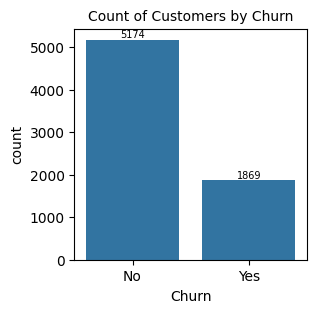

In [24]:
fig, ax = plt.subplots(figsize=(3,3))
ax = sns.countplot(x = "Churn", data = df)
ax.bar_label(ax.containers[0], fontsize = 7)
plt.title("Count of Customers by Churn", fontsize = 10)
plt.show()

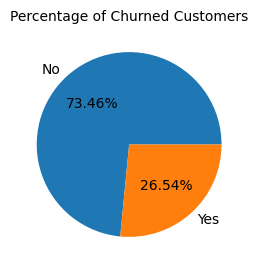

In [47]:
plt.figure(figsize = (3,3))
gb = df.groupby("Churn")['Churn'].count() 
plt.pie(gb, labels=gb.index, autopct='%1.2f%%')
plt.title("Percentage of Churned Customers", fontsize = 10)
plt.show()

From the given pie chart we can conclude that 26.54% of customers have churned out.

Now lets's explore the reason behind it.

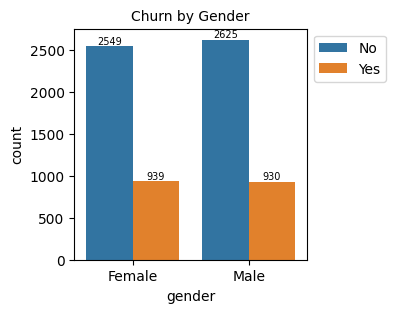

In [72]:
plt.figure(figsize = (3,3))
ax = sns.countplot(x = "gender", data = df, hue = "Churn")
ax.bar_label(ax.containers[0], fontsize = 7)
ax.bar_label(ax.containers[1], fontsize = 7)
plt.title("Churn by Gender", fontsize = 10)
plt.legend(bbox_to_anchor = (1,1))
plt.show()

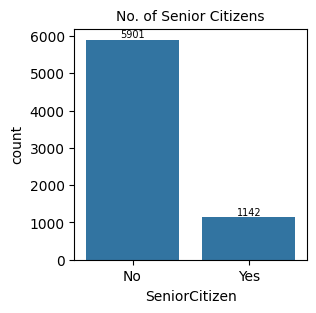

In [70]:
plt.figure(figsize = (3,3))
ax = sns.countplot(x = "SeniorCitizen",data = df)
ax.bar_label(ax.containers[0], fontsize = 7)
plt.title("No. of Senior Citizens", fontsize = 10)
plt.show()

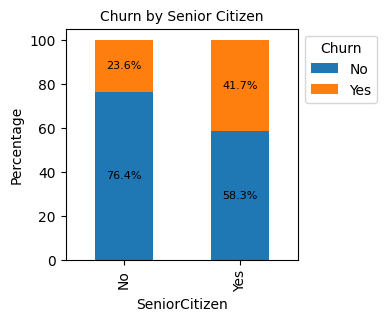

In [69]:
at = pd.crosstab(df['SeniorCitizen'], df['Churn'])
# Convert to percentage of total per SeniorCitizen group
at_pct = at.div(at.sum(axis=1), axis=0) * 100
# Plot stacked bar
ax = at_pct.plot(kind='bar', stacked=True, figsize=(3,3))
plt.title("Churn by Senior Citizen", fontsize=10)
plt.ylabel("Percentage")
# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)
plt.legend(title='Churn', bbox_to_anchor = (1,1))
plt.show()

Comparitively a greater no. of people in senior citizens category have churned.

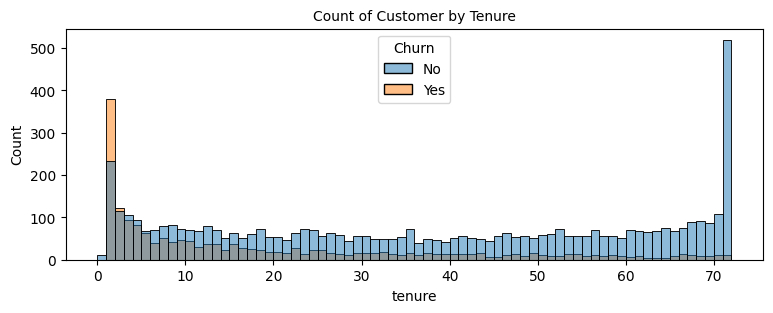

In [89]:
plt.figure(figsize = (9,3))
sns.histplot(x = "tenure", data = df, bins = 72, hue = "Churn")
plt.title("Count of Customer by Tenure", fontsize = 10)
plt.show()

People who have used our services for a long time have stayed and people who have used our services for 1 or 2 months have churned.

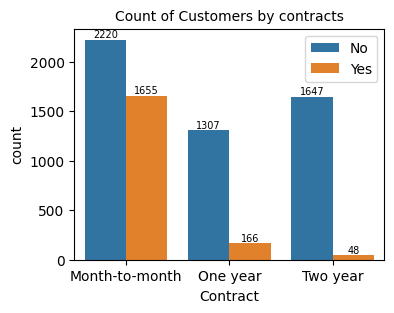

In [86]:
plt.figure(figsize = (4,3))
ax = sns.countplot(x = "Contract",data = df, hue = "Churn")
ax.bar_label(ax.containers[0], fontsize = 7)
ax.bar_label(ax.containers[1], fontsize = 7)
plt.title("Count of Customers by contracts", fontsize = 10)
plt.legend(bbox_to_anchor = (1,1))
plt.show()

People who are having month to month contract are more likely to churn than from those who have 1 or 2 year contract

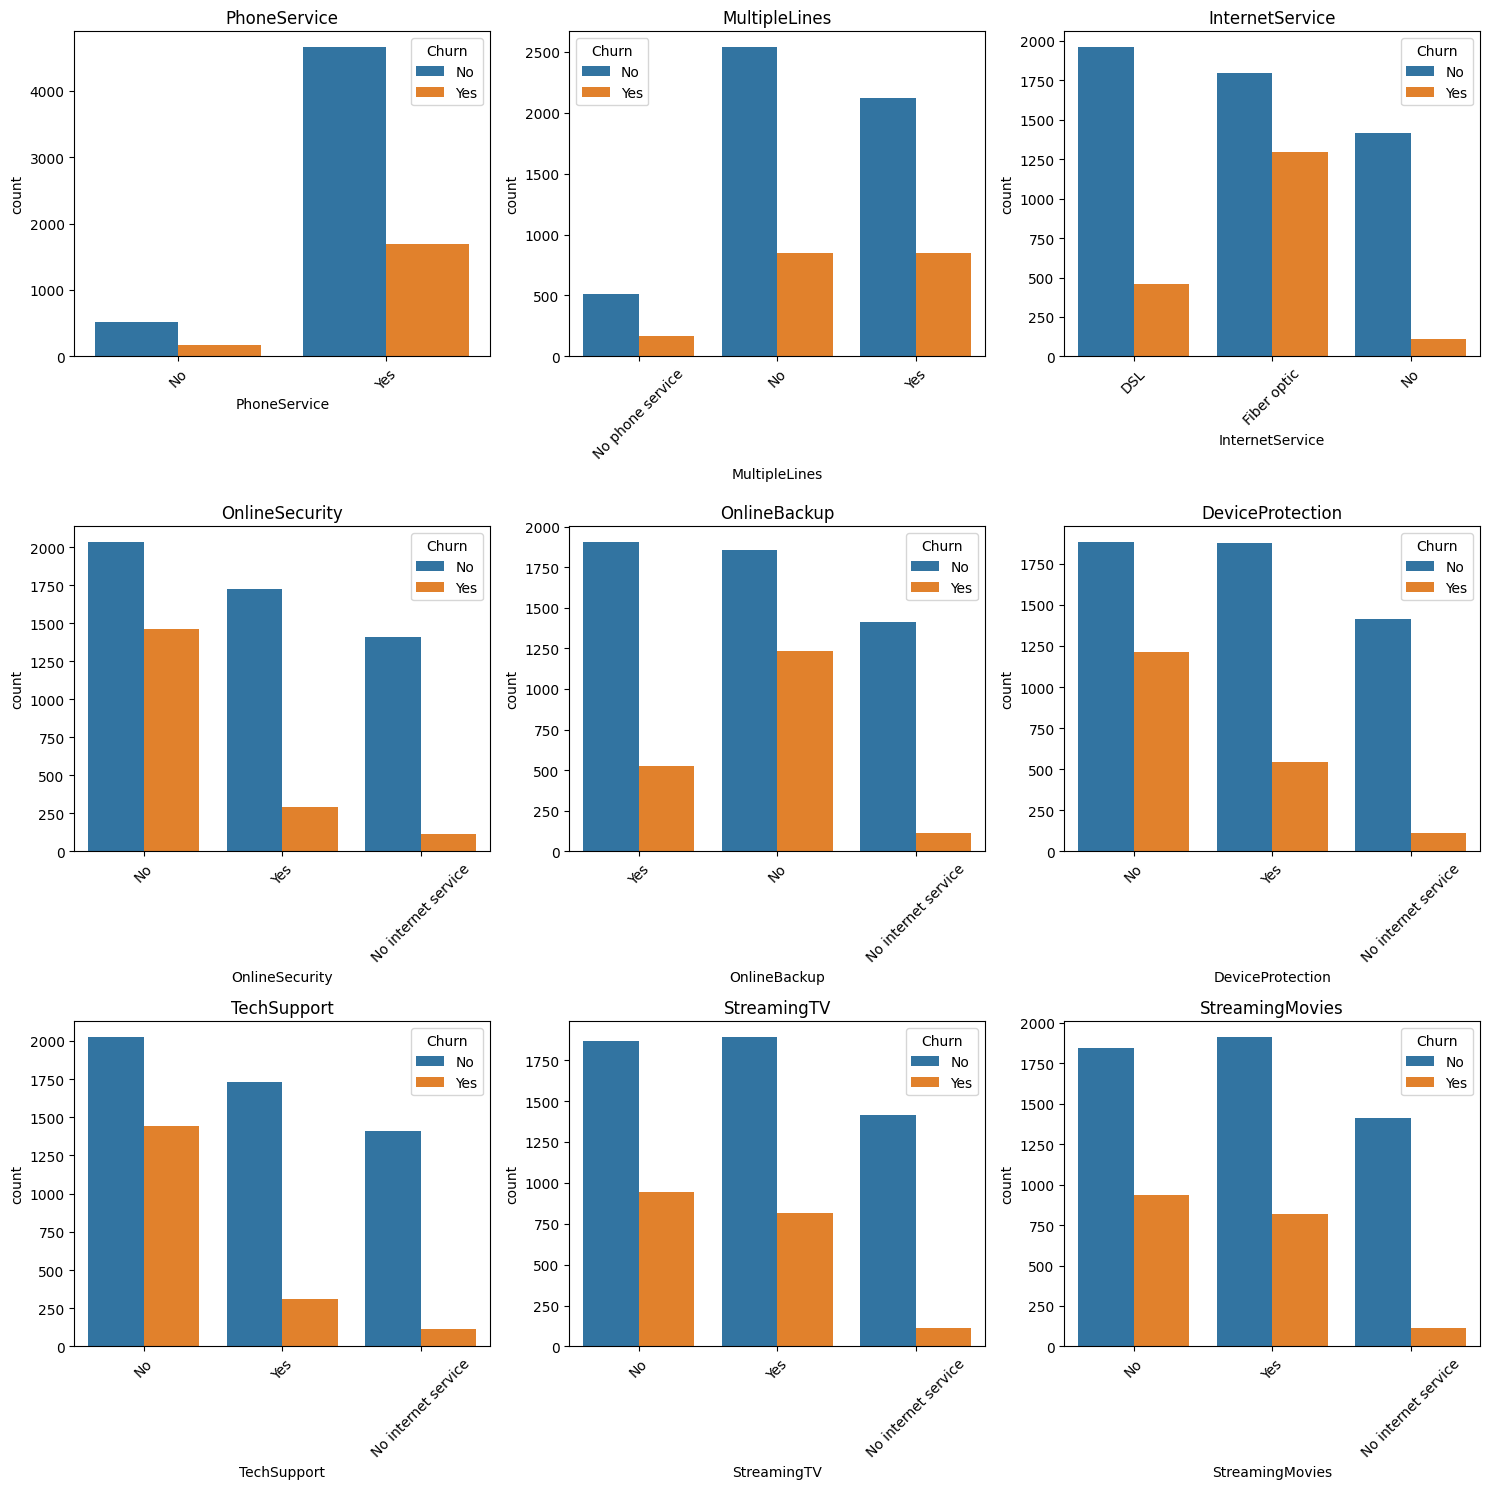

In [85]:
cols = ['PhoneService','MultipleLines','InternetService',
        'OnlineSecurity','OnlineBackup','DeviceProtection',
        'TechSupport','StreamingTV','StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(15,15))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(x=df[col], ax=axes[i], hue = df["Churn"])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Customers without Online Security or Tech Support show substantially higher churn compared to those who have these services.
Churn is also noticeably higher among users with Fiber optic Internet Service than those with DSL or no internet service.
Customers who lack Online Backup or Device Protection tend to churn more frequently.
Features like Streaming TV, Streaming Movies, and Multiple Lines show weaker differences, indicating they have a smaller impact on churn.

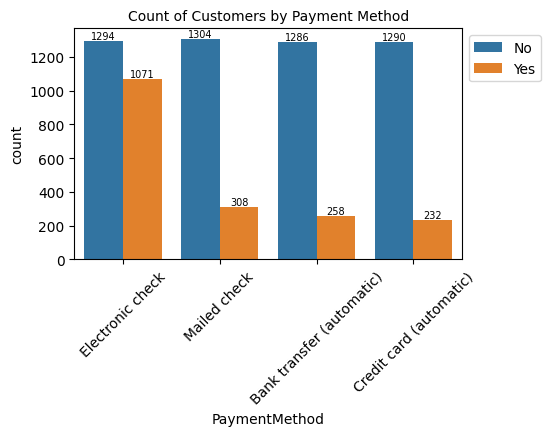

In [94]:
plt.figure(figsize = (5,3))
ax = sns.countplot(x = "PaymentMethod",data = df, hue = "Churn")
ax.bar_label(ax.containers[0], fontsize = 7)
ax.bar_label(ax.containers[1], fontsize = 7)
plt.title("Count of Customers by Payment Method", fontsize = 10)
plt.xticks(rotation = 45)
plt.legend(bbox_to_anchor = (1,1))
plt.show()

Customer using Electronic check are most likely to churn